# How are in-demand skills trending for Data Analysts?

### Methology

1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [44]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [45]:
df_DA_CH = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Switzerland')].copy()

In [46]:
df_DA_CH['job_posted_month_no'] = df_DA_CH['job_posted_date'].dt.month

In [47]:
df_DA_CH_explode = df_DA_CH.explode('job_skills')

In [48]:
df_DA_CH_pivot = df_DA_CH_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_CH_pivot.loc['Total'] = df_DA_CH_pivot.sum()

df_DA_CH_pivot = df_DA_CH_pivot[df_DA_CH_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_CH_pivot = df_DA_CH_pivot.drop('Total')

df_DA_CH_pivot

job_skills,sql,python,excel,tableau,r,power bi,sap,azure,sas,oracle,...,powerbi,redhat,swift,symfony,sqlite,trello,visio,typescript,watson,yarn
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,171,135,83,56,87,57,29,16,22,28,...,0,1,0,0,1,0,0,0,1,0
2,126,88,48,43,54,27,9,20,12,20,...,0,0,0,0,0,0,1,0,0,1
3,103,77,63,59,37,27,25,14,6,21,...,0,0,0,1,0,0,0,0,0,0
4,122,77,52,53,45,41,34,22,24,8,...,0,0,0,0,0,0,0,0,0,0
5,77,50,38,47,25,26,30,10,12,6,...,0,0,0,0,0,0,0,0,0,0
6,87,78,60,38,49,21,27,15,14,9,...,0,0,0,0,0,0,0,0,0,0
7,62,62,35,35,38,26,20,18,4,3,...,1,0,0,0,0,0,0,0,0,0
8,87,71,41,39,43,27,23,15,12,12,...,0,0,0,0,0,0,0,1,0,0
9,57,52,33,29,24,19,14,5,8,3,...,0,0,0,0,0,0,0,0,0,0


In [49]:
DA_totals =df_DA_CH.groupby('job_posted_month_no').size()
DA_totals

job_posted_month_no
1     457
2     225
3     240
4     215
5     163
6     208
7     169
8     223
9     123
10     97
11    110
12    113
dtype: int64

In [50]:
df_DA_percent = df_DA_CH_pivot.div(DA_totals/100, axis=0)
df_DA_percent

job_skills,sql,python,excel,tableau,r,power bi,sap,azure,sas,oracle,...,powerbi,redhat,swift,symfony,sqlite,trello,visio,typescript,watson,yarn
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,37.417943,29.540481,18.161926,12.253829,19.037199,12.472648,6.345733,3.501094,4.814004,6.126915,...,0.000000,0.218818,0.000000,0.000000,0.218818,0.000000,0.000000,0.00000,0.218818,0.000000
2,56.000000,39.111111,21.333333,19.111111,24.000000,12.000000,4.000000,8.888889,5.333333,8.888889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.444444,0.00000,0.000000,0.444444
3,42.916667,32.083333,26.250000,24.583333,15.416667,11.250000,10.416667,5.833333,2.500000,8.750000,...,0.000000,0.000000,0.000000,0.416667,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,56.744186,35.813953,24.186047,24.651163,20.930233,19.069767,15.813953,10.232558,11.162791,3.720930,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
5,47.239264,30.674847,23.312883,28.834356,15.337423,15.950920,18.404908,6.134969,7.361963,3.680982,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,41.826923,37.500000,28.846154,18.269231,23.557692,10.096154,12.980769,7.211538,6.730769,4.326923,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
7,36.686391,36.686391,20.710059,20.710059,22.485207,15.384615,11.834320,10.650888,2.366864,1.775148,...,0.591716,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,39.013453,31.838565,18.385650,17.488789,19.282511,12.107623,10.313901,6.726457,5.381166,5.381166,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.44843,0.000000,0.000000
9,46.341463,42.276423,26.829268,23.577236,19.512195,15.447154,11.382114,4.065041,6.504065,2.439024,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [51]:
df_DA_percent = df_DA_percent.reset_index()
df_DA_percent['job_posted_month'] = df_DA_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_percent = df_DA_percent.set_index('job_posted_month')
df_DA_percent = df_DA_percent.drop(columns='job_posted_month_no')

df_DA_percent

job_skills,sql,python,excel,tableau,r,power bi,sap,azure,sas,oracle,...,powerbi,redhat,swift,symfony,sqlite,trello,visio,typescript,watson,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,37.417943,29.540481,18.161926,12.253829,19.037199,12.472648,6.345733,3.501094,4.814004,6.126915,...,0.000000,0.218818,0.000000,0.000000,0.218818,0.000000,0.000000,0.00000,0.218818,0.000000
Feb,56.000000,39.111111,21.333333,19.111111,24.000000,12.000000,4.000000,8.888889,5.333333,8.888889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.444444,0.00000,0.000000,0.444444
Mar,42.916667,32.083333,26.250000,24.583333,15.416667,11.250000,10.416667,5.833333,2.500000,8.750000,...,0.000000,0.000000,0.000000,0.416667,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Apr,56.744186,35.813953,24.186047,24.651163,20.930233,19.069767,15.813953,10.232558,11.162791,3.720930,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
May,47.239264,30.674847,23.312883,28.834356,15.337423,15.950920,18.404908,6.134969,7.361963,3.680982,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Jun,41.826923,37.500000,28.846154,18.269231,23.557692,10.096154,12.980769,7.211538,6.730769,4.326923,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Jul,36.686391,36.686391,20.710059,20.710059,22.485207,15.384615,11.834320,10.650888,2.366864,1.775148,...,0.591716,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Aug,39.013453,31.838565,18.385650,17.488789,19.282511,12.107623,10.313901,6.726457,5.381166,5.381166,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.44843,0.000000,0.000000
Sep,46.341463,42.276423,26.829268,23.577236,19.512195,15.447154,11.382114,4.065041,6.504065,2.439024,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


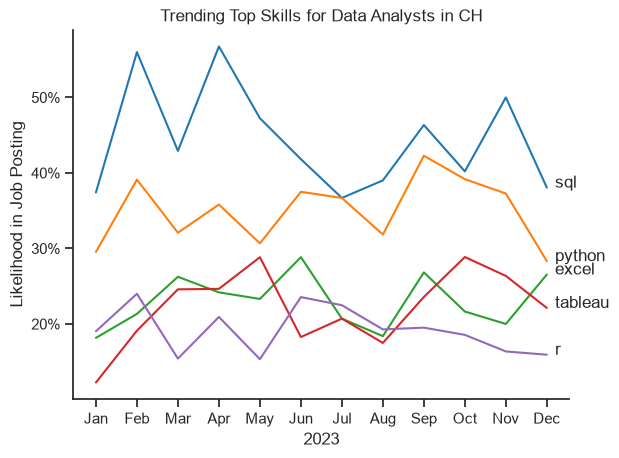

In [59]:
df_plot = df_DA_percent.iloc[:,:5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Trending Top Skills for Data Analysts in CH')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i])